In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Crear DataFrame con los datos de la tabla
data = {
    "Comisiones": [22,13,33,38,23,47,29,38,41,32,20,13,47,
                   38,44,29,38,37,14,34,25,27,25,43,34],
    
    "Llamadas": [139,132,144,142,142,142,138,139,144,134,135,137,146,
                 146,144,147,144,149,131,144,132,132,127,154,147],
    
    "Millas": [2371,2226,2731,3351,2289,3449,3114,3342,2842,2625,2121,2219,3463,
               3290,3103,2122,2791,3209,2287,2848,2690,2933,2671,2988,2829]
}

df = pd.DataFrame(data)

df.head()


,Comisiones,Llamadas,Millas
0,22,139,2371
1,13,132,2226
2,33,144,2731
3,38,142,3351
4,23,142,2289


In [18]:
X = df[['Millas', 'Llamadas']]
y = df[['Comisiones']]


In [19]:
model = LinearRegression()
model.fit(X,y)

y_pred = model.predict(X)

mse = mean_squared_error(y,y_pred)
r2 = r2_score(y,y_pred)


In [20]:
print("Intercepto:", model.intercept_)
print("Coeficientes:", model.coef_)
print("Error cuadrático medio:", mse)
print("R²:", r2)


Intercepto: [-101.31444968]
Coeficientes: [[0.01568925 0.63233256]]
Error cuadrático medio: 16.313412727936058
R²: 0.8352686374291525


In [21]:
Y = model.predict([[3000,140]])
print("Comisión estimada:", Y)


Comisión estimada: [[34.27987128]]


c:\Users\alexi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


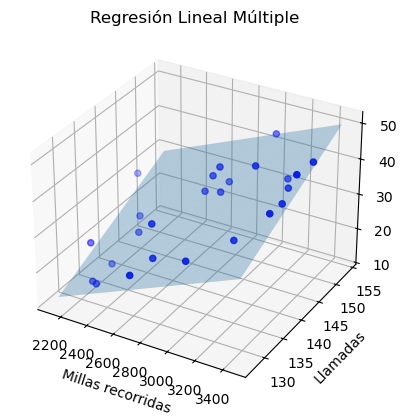

In [22]:
# Crear figura 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Datos reales
ax.scatter(df['Millas'], df['Llamadas'], df['Comisiones'], color='blue')

ax.set_xlabel('Millas recorridas')
ax.set_ylabel('Llamadas')
ax.set_zlabel('Comisiones')

# Crear malla para el plano
x_surf, y_surf = np.meshgrid(
    np.linspace(df['Millas'].min(), df['Millas'].max(), 10),
    np.linspace(df['Llamadas'].min(), df['Llamadas'].max(), 10)
)

# Ecuación del plano
z_surf = (model.intercept_ 
          + model.coef_[0][0] * x_surf 
          + model.coef_[0][1] * y_surf)

# Dibujar plano
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.3)

plt.title("Regresión Lineal Múltiple")
plt.show()

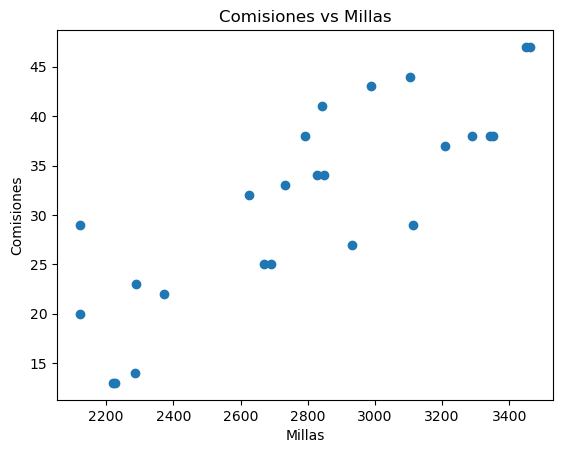

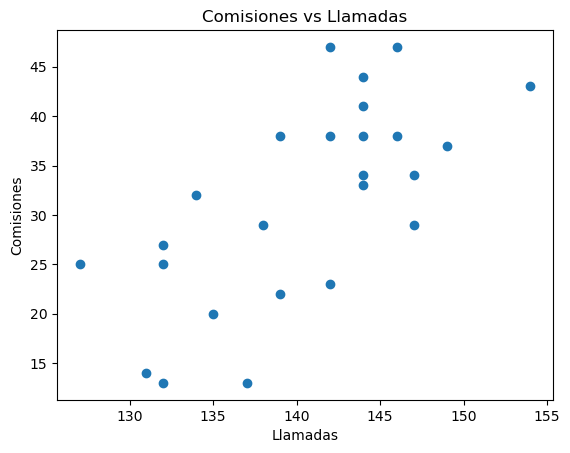

In [23]:
plt.scatter(df['Millas'], df['Comisiones'])
plt.xlabel("Millas")
plt.ylabel("Comisiones")
plt.title("Comisiones vs Millas")
plt.show()

plt.scatter(df['Llamadas'], df['Comisiones'])
plt.xlabel("Llamadas")
plt.ylabel("Comisiones")
plt.title("Comisiones vs Llamadas")
plt.show()


# Interpretacion
El modelo de regresión lineal múltiple permite analizar cómo influyen simultáneamente el número de millas recorridas y el número de llamadas realizadas en las comisiones obtenidas. Si el valor de R² es alto, significa que ambas variables explican en buena medida el comportamiento de las comisiones. Además, los coeficientes indican cuánto aumenta la comisión promedio cuando aumentan las millas o las llamadas, manteniendo constante la otra variable. En general, se espera una relación positiva, ya que recorrer más millas y realizar más llamadas debería generar mayores ventas y, por lo tanto, mayores comisiones.